In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
fraud=pd.read_csv("Fraud.csv")
fraud

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
# ---------------------------------------------------------Data exploration------------------------------------------------------------------------------------------------------------------------------------------------

In [4]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
fraud.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [6]:
fraud.shape

(6362620, 11)

In [7]:
fraud.head(7)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0
6,1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0,0,0


In [6]:
print(fraud.head(7)["step"].sum())
print(fraud.head(7)["amount"].sum())
print(fraud.head(7)["oldbalanceOrg"].sum())
print(fraud.head(7)["newbalanceOrig"].sum())
print(fraud.head(7)["oldbalanceDest"].sum())
print(fraud.head(7)["newbalanceDest"].sum())
print(fraud.head(7)["isFraud"].sum())
print(fraud.head(7)["isFlaggedFraud"].sum())


7
38659.53999999999
470356.0
431696.46
21182.0
0.0
2
0


In [9]:
print(fraud.head(7)["step"].min())
print(fraud.head(7)["type"].max())
print(fraud.head(7)["amount"].mean())
print(fraud.head(7)["amount"].mode())

1
TRANSFER
5522.791428571428
0    181.0
Name: amount, dtype: float64


In [10]:
fraud.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.00,0.00,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
print(fraud.tail(10)["step"].sum())
print(fraud.tail(10)["amount"].sum())
print(fraud.tail(10)["oldbalanceOrg"].sum())
print(fraud.tail(10)["newbalanceOrig"].sum())
print(fraud.tail(10)["oldbalanceDest"].sum())
print(fraud.tail(10)["newbalanceDest"].sum())
print(fraud.tail(10)["isFraud"].sum())
print(fraud.tail(10)["isFlaggedFraud"].sum())

7428
17646659.48
17646659.48
0.0
7358485.63
16181815.370000001
10
0


In [12]:
print(fraud.tail(10)["step"].min())
print(fraud.tail(10)["type"].max())
print(fraud.tail(10)["amount"].mean())
print(fraud.tail(10)["amount"].mode())

742
TRANSFER
1764665.948
0      63416.99
1     339682.13
2     850002.52
3    1258818.82
4    6311409.28
Name: amount, dtype: float64


In [13]:
fraud.value_counts().head(10)

step  type      amount     nameOrig     oldbalanceOrg  newbalanceOrig  nameDest     oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud
1     CASH_IN   270.78     C619985571   4184966.65     4185237.43      C875917495   3019.00         0.00            0        0                 1
306   CASH_OUT  220427.13  C1029846599  0.00           0.00            C129321077   882543.64       1102970.77      0        0                 1
                221047.89  C644407995   13756.00       0.00            C1396283314  9082.00         0.00            0        0                 1
                221009.03  C74685400    102768.00      0.00            C1714223283  767644.73       988653.76       0        0                 1
                220986.46  C540058568   9141.00        0.00            C1344091292  0.00            220986.46       0        0                 1
                220960.80  C555707380   0.00           0.00            C446549282   888445.42       1109406.22      0        0         

In [14]:
fraud.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [15]:
fraud.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [16]:
fraud.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1902386530,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [17]:
fraud.isnull()
fraud

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [18]:
fraud["amount"].isnull().sum()

np.int64(0)

In [19]:
fraud.duplicated().info()

<class 'pandas.core.series.Series'>
RangeIndex: 6362620 entries, 0 to 6362619
Series name: None
Non-Null Count    Dtype
--------------    -----
6362620 non-null  bool 
dtypes: bool(1)
memory usage: 6.1 MB


In [20]:
fraud.duplicated(subset="amount").head(6)

0    False
1    False
2    False
3     True
4    False
5    False
dtype: bool

In [21]:
fraud.duplicated(subset=["isFraud"]).sum()

np.int64(6362618)

In [ ]:
# ----------------------------------------------------------------------------Data exploration--------------------------------------------------------------------------------------------------

In [ ]:
# ---------------------------------------------------------------------------------------------------------------------------Data cleaning---------------------------------------------------------------------------------------------------------

In [24]:
fraud.fillna(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [25]:
fraud["type"].fillna(5).head()

0     PAYMENT
1     PAYMENT
2    TRANSFER
3    CASH_OUT
4     PAYMENT
Name: type, dtype: object

In [26]:
fraud["isFraud"].fillna(fraud["amount"])

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

In [27]:
fraud.dropna()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [28]:
# -------------------------------------------------------------------------------------------using operator---------------------------------------------------------------------------------------------------------------

In [29]:
print(fraud[fraud["amount"]>=50000])

         step      type      amount     nameOrig  oldbalanceOrg  \
15          1  CASH_OUT   229133.94   C905080434       15325.00   
19          1  TRANSFER   215310.30  C1670993182         705.00   
24          1  TRANSFER   311685.89  C1984094095       10835.00   
42          1  CASH_OUT   110414.71   C768216420       26845.41   
47          1  CASH_OUT    56953.90  C1570470538        1942.02   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
15                  0.0   C476402209         5083.00        51513.44        0   
19                  0.0  C1100439

In [30]:
print(fraud[fraud["oldbalanceOrg"]<=15000])

         step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2           1  TRANSFER   181.00  C1305486145         181.00            0.00   
3           1  CASH_OUT   181.00   C840083671         181.00            0.00   
8           1   PAYMENT  4024.36  C1265012928        2671.00            0.00   
10          1     DEBIT  9644.94  C1900366749        4465.00            0.00   
12          1   PAYMENT  2560.74  C1648232591        5070.00         2509.26   
...       ...       ...      ...          ...            ...             ...   
6362461   730  CASH_OUT     0.00   C729003789           0.00            0.00   
6362463   730  CASH_OUT     0.00  C2088151490           0.00            0.00   
6362566   739  TRANSFER  8116.53  C2072430566        8116.53            0.00   
6362567   739  CASH_OUT  8116.53   C564539602        8116.53            0.00   
6362585   741  CASH_OUT     0.00   C312737633           0.00            0.00   

            nameDest  oldbalanceDest  n

In [31]:
# ----------------------------------------------------------------using operator------------------------------------------------------------------------------------------

In [32]:
# ----------------------------------------------------------------------------charts--------------------------------------------------------------------------------------

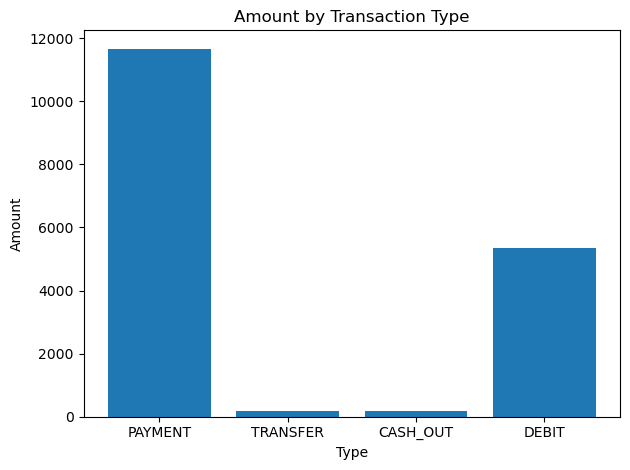

In [8]:
plt.bar(fraud["type"].head(10), fraud["amount"].head(10))
plt.title("Amount by Transaction Type")
plt.xlabel("Type")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

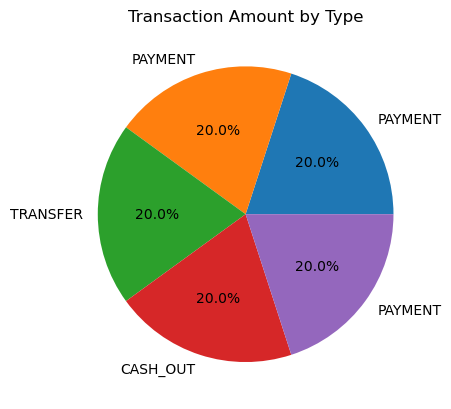

In [34]:
plt.pie(fraud["step"].head(),labels=fraud["type"].head(),autopct="%1.1f%%")
plt.title("Transaction Amount by Type")
plt.show()

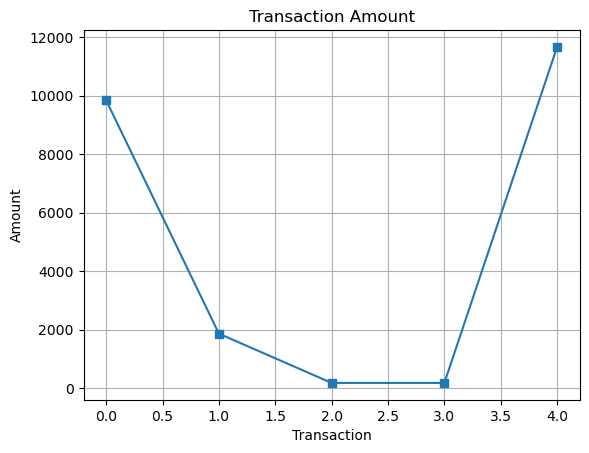

In [9]:
plt.plot(fraud["amount"].head(),marker="s")
plt.title("Transaction Amount")
plt.xlabel("Transaction")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

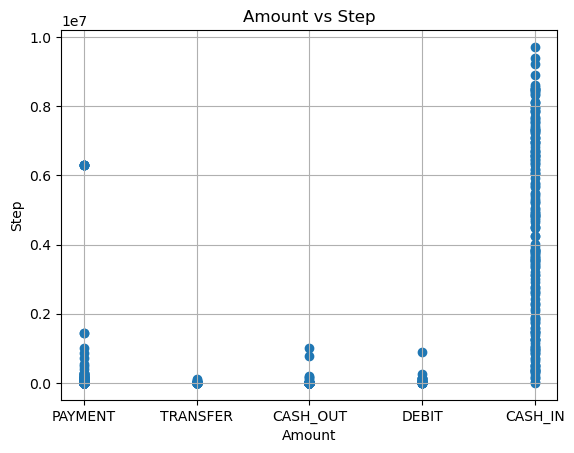

In [36]:
plt.scatter(fraud["type"].head(710),fraud["oldbalanceOrg"].head(710))
plt.title("Amount vs Step")
plt.xlabel("Amount")
plt.ylabel("Step")
plt.grid(True)
plt.show()

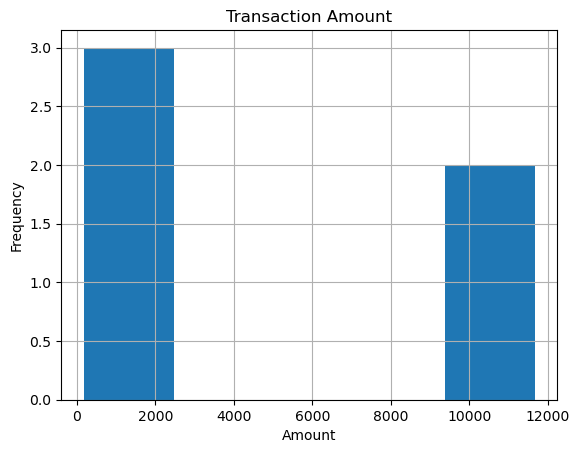

In [37]:
plt.hist(fraud["amount"].head(),bins=5)
plt.title("Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [38]:
fraud.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

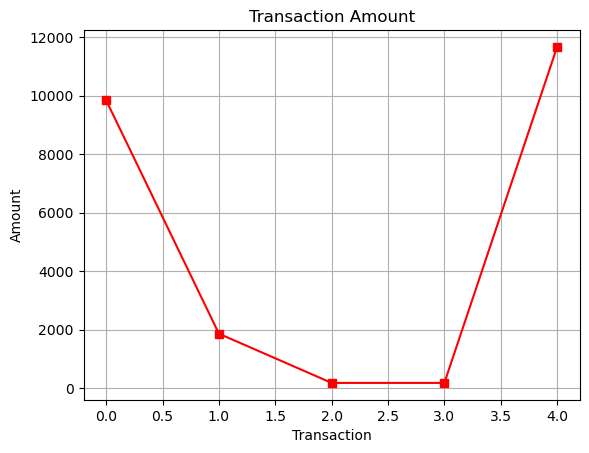

In [39]:
plt.plot(fraud["amount"].head(),color="red",marker="s")
plt.title("Transaction Amount")
plt.xlabel("Transaction")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

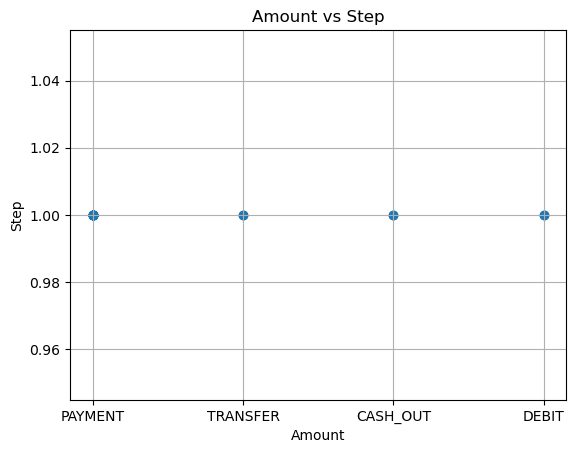

In [40]:
plt.scatter(fraud["type"].head(20), fraud["step"].head(20))
plt.title("Amount vs Step")
plt.xlabel("Amount")
plt.ylabel("Step")
plt.grid(True)
plt.show()

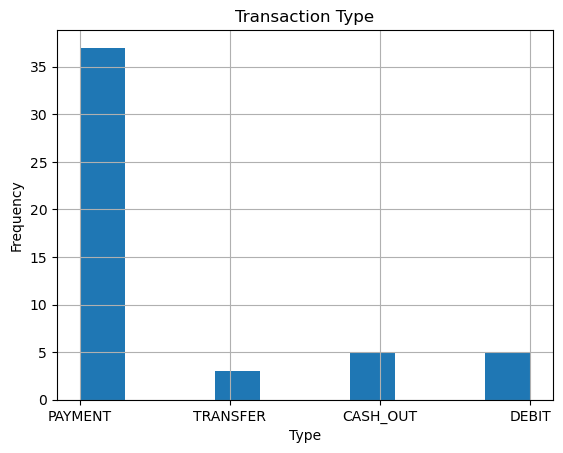

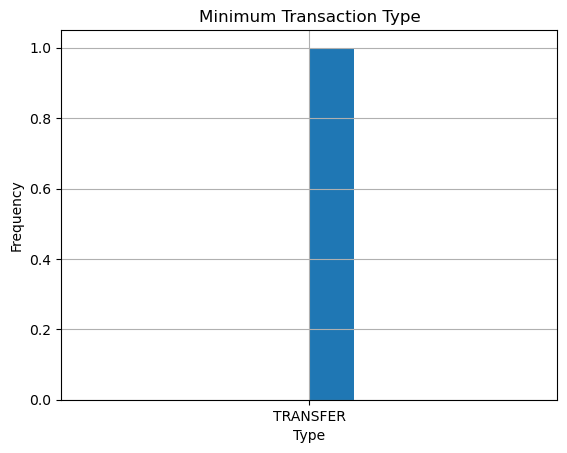

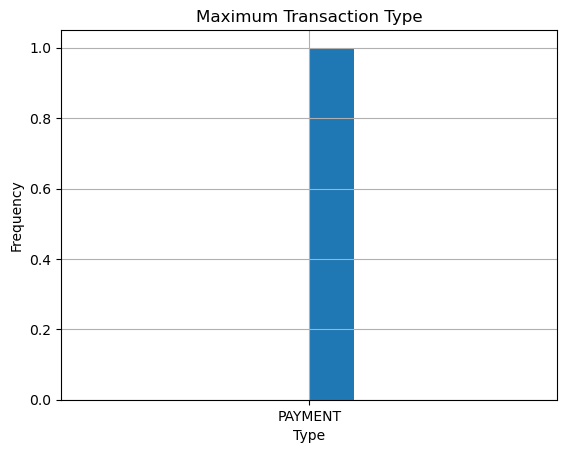

In [ ]:
fra_det=fraud["type"].head(50)
plt.hist(fra_det)
plt.title("Transaction Type")
plt.xlabel("Type")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
# Minimum 
min=fra_det.value_counts().idxmin()
plt.hist(min)
plt.title("Minimum Transaction Type")
plt.xlabel("Type")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
# Maximum 
max=fra_det.value_counts().idxmax()
plt.hist(max)
plt.title("Maximum Transaction Type")
plt.xlabel("Type")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [42]:
# -------------------------------------------------------------------------------------------charts------------------------------------------------------------------------------------------------------------------------

In [43]:
# -----------------------------------------------------------------------------------------------plots--------------------------------------------------------------------------------------------------------------------

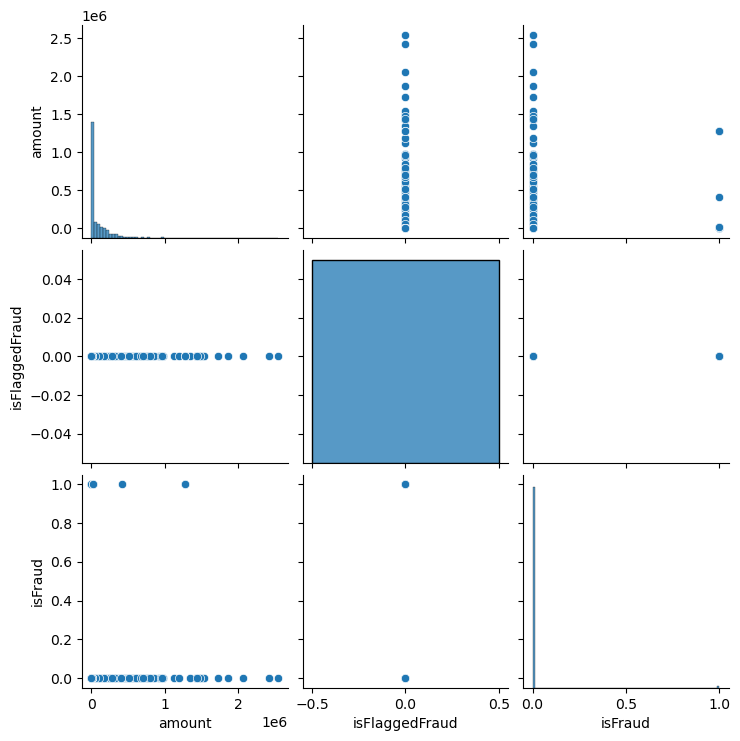

In [44]:
sns.pairplot(fraud[["amount","isFlaggedFraud","isFraud"]].head(1000))
plt.show()

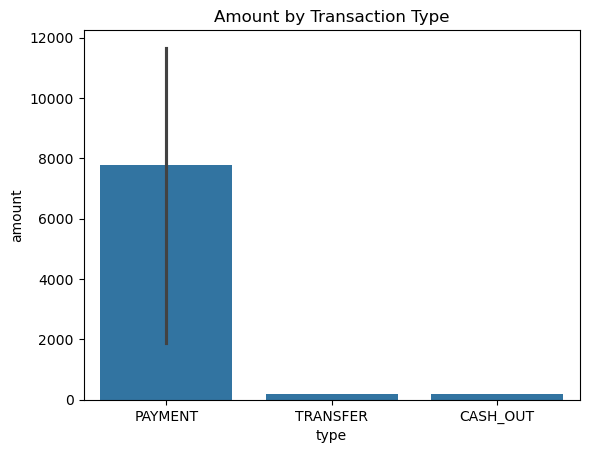

In [45]:
sns.barplot(data=fraud.head(),x="type",y="amount")
plt.title("Amount by Transaction Type")
plt.show()

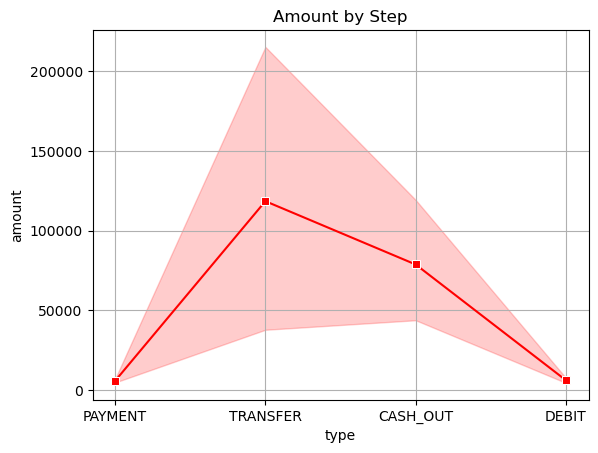

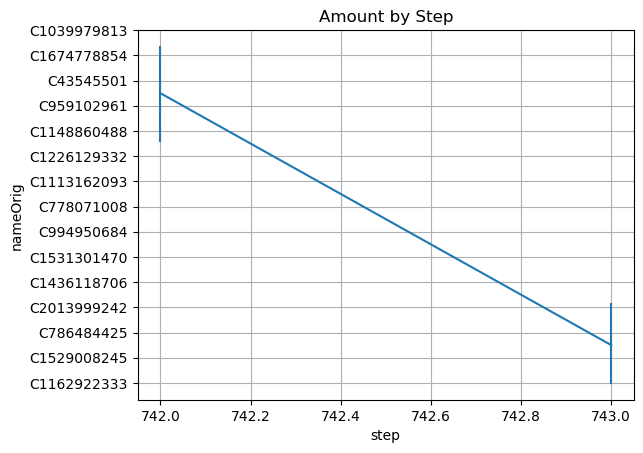

In [15]:
sns.lineplot(data=fraud.head(80),x="type", y="amount",err_style="band",color="red",marker="s")
plt.title("Amount by Step")
plt.grid()
plt.show()

sns.lineplot(data=fraud.tail(20),x="step", y="nameOrig",err_style="bars")
plt.title("Amount by Step")
plt.grid()
plt.show()

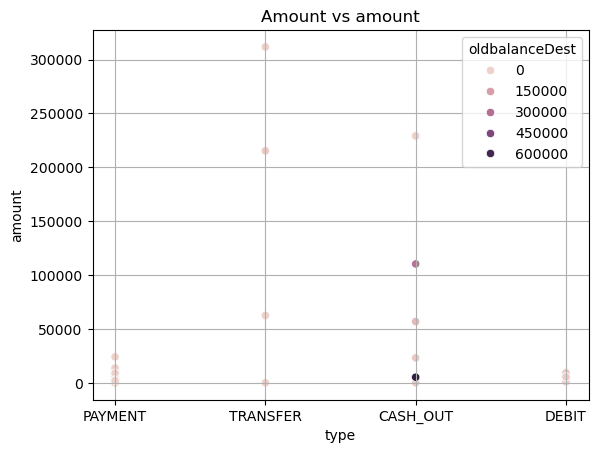

In [4]:
sns.scatterplot(data=fraud.head(60), x="type", y="amount",hue="oldbalanceDest")
plt.title("Amount vs amount")
plt.grid()
plt.show()

In [48]:
fraud.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

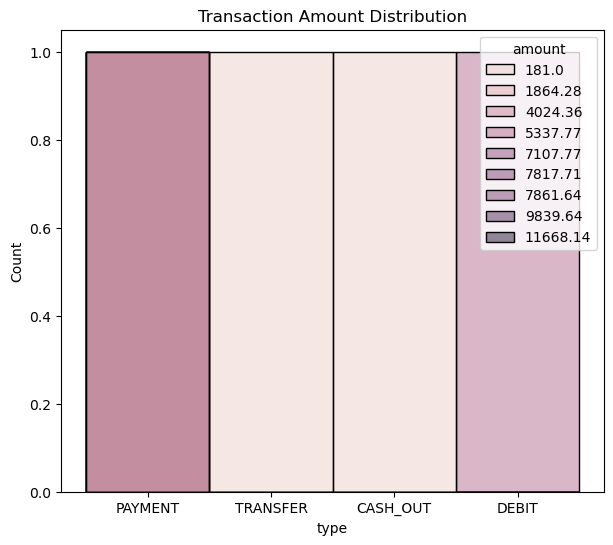

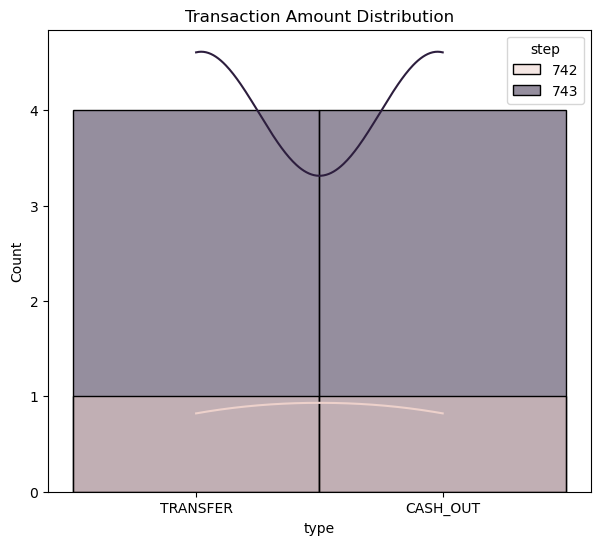

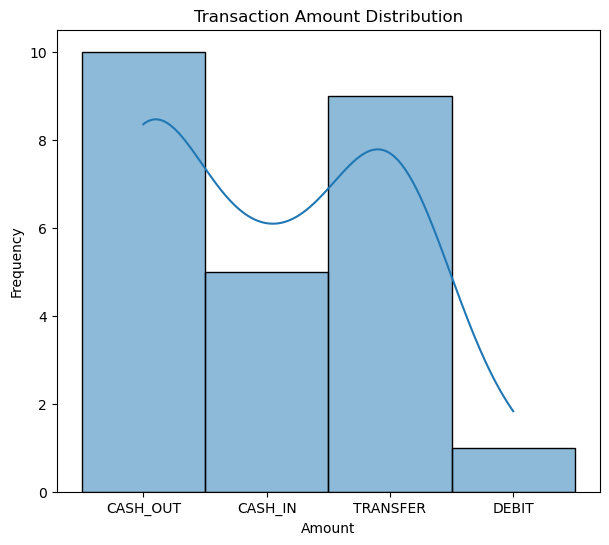

In [49]:
plt.figure(figsize=(7,6))
sns.histplot(data=fraud.head(10), x="type",hue="amount")
plt.title("Transaction Amount Distribution")
plt.show()

plt.figure(figsize=(7,6))
sns.histplot(data=fraud.tail(10), x="type",hue="step",kde="True")
plt.title("Transaction Amount Distribution")
plt.show()

plt.figure(figsize=(7,6))
sns.histplot(data=fraud.nlargest(25,"oldbalanceDest"), x="type",kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout
plt.show()

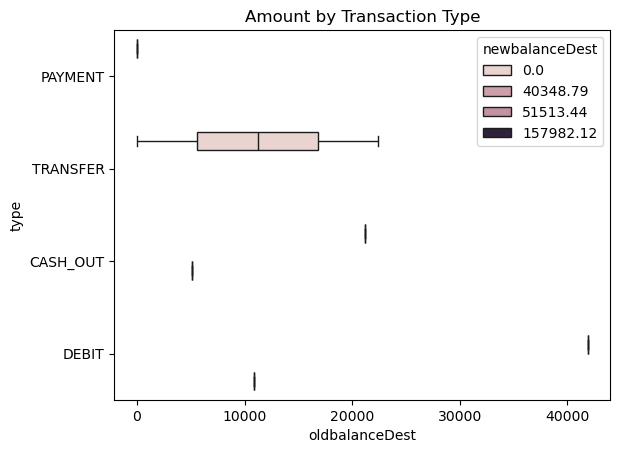

In [5]:
sns.boxplot(data=fraud.head(20), x="oldbalanceDest", y="type",hue="newbalanceDest")
plt.title("Amount by Transaction Type")
plt.show()

In [51]:
fraud.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

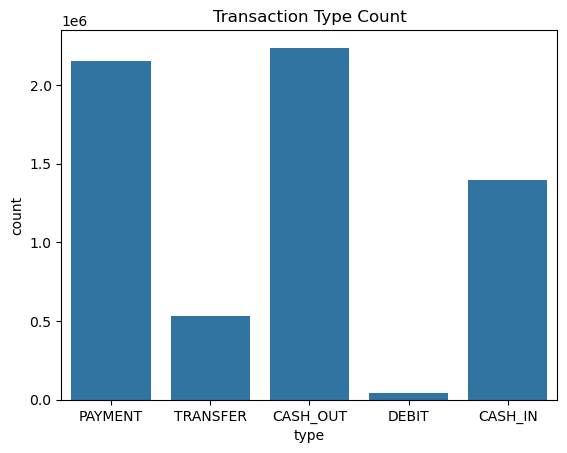

In [52]:
sns.countplot(data=fraud,x="type")
plt.title("Transaction Type Count")
plt.show()

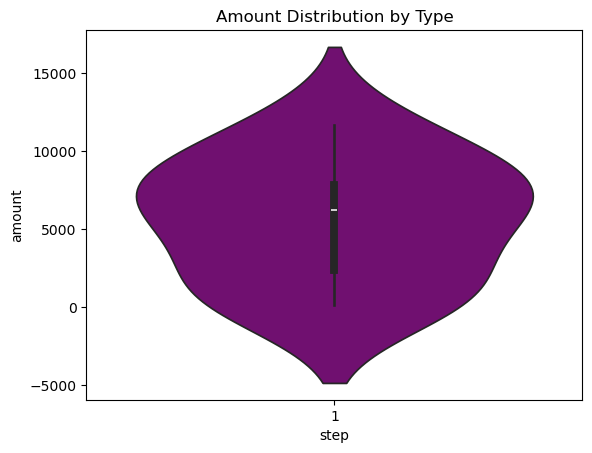

In [20]:
sns.violinplot(data=fraud.head(10),x="step",y="amount",color="purple")
plt.title("Amount Distribution by Type")
plt.show()

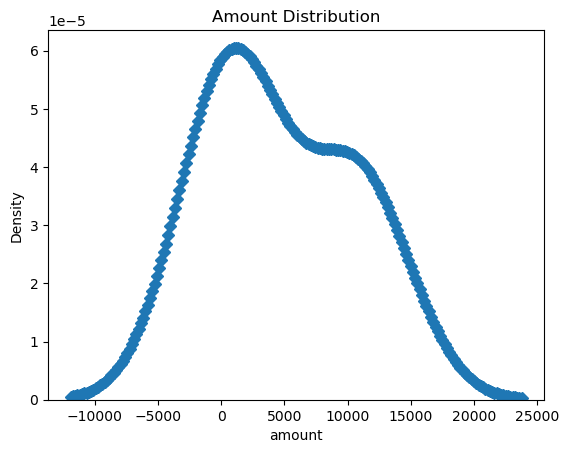

In [54]:
sns.kdeplot(data=fraud.head(), x="amount",marker="D")
plt.title("Amount Distribution")
plt.show()

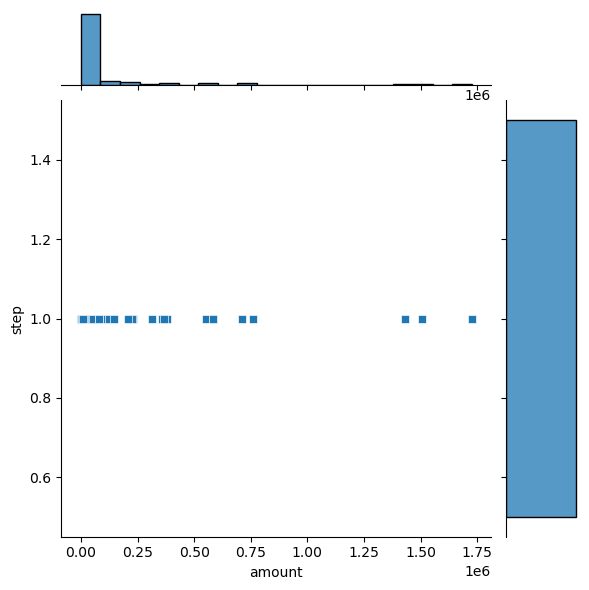

In [55]:
sns.jointplot(data=fraud.head(100), x="amount", y="step",marker="s")
plt.show()

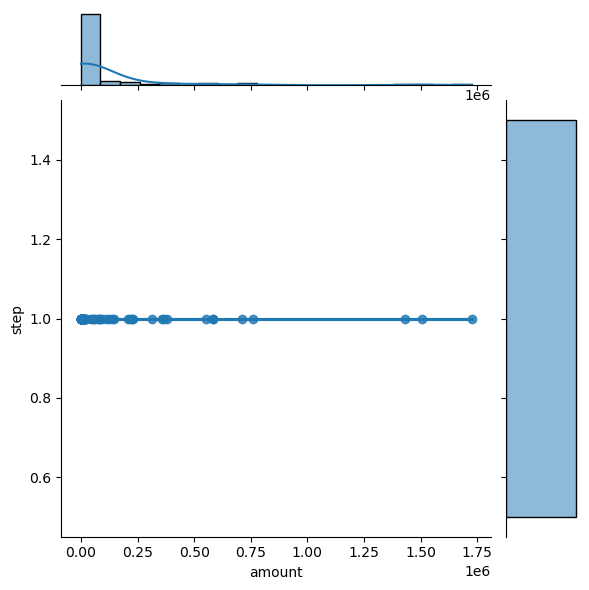

In [56]:
sns.jointplot(data=fraud.head(100), x="amount",y="step",kind="reg")
plt.show()

In [57]:
# --------------------------------------------------------------------------------plots-----------------------------------------------------------------------------------

In [58]:
# --------------------------------------------------------------------------------Dash boards-----------------------------------------------------------------------------------

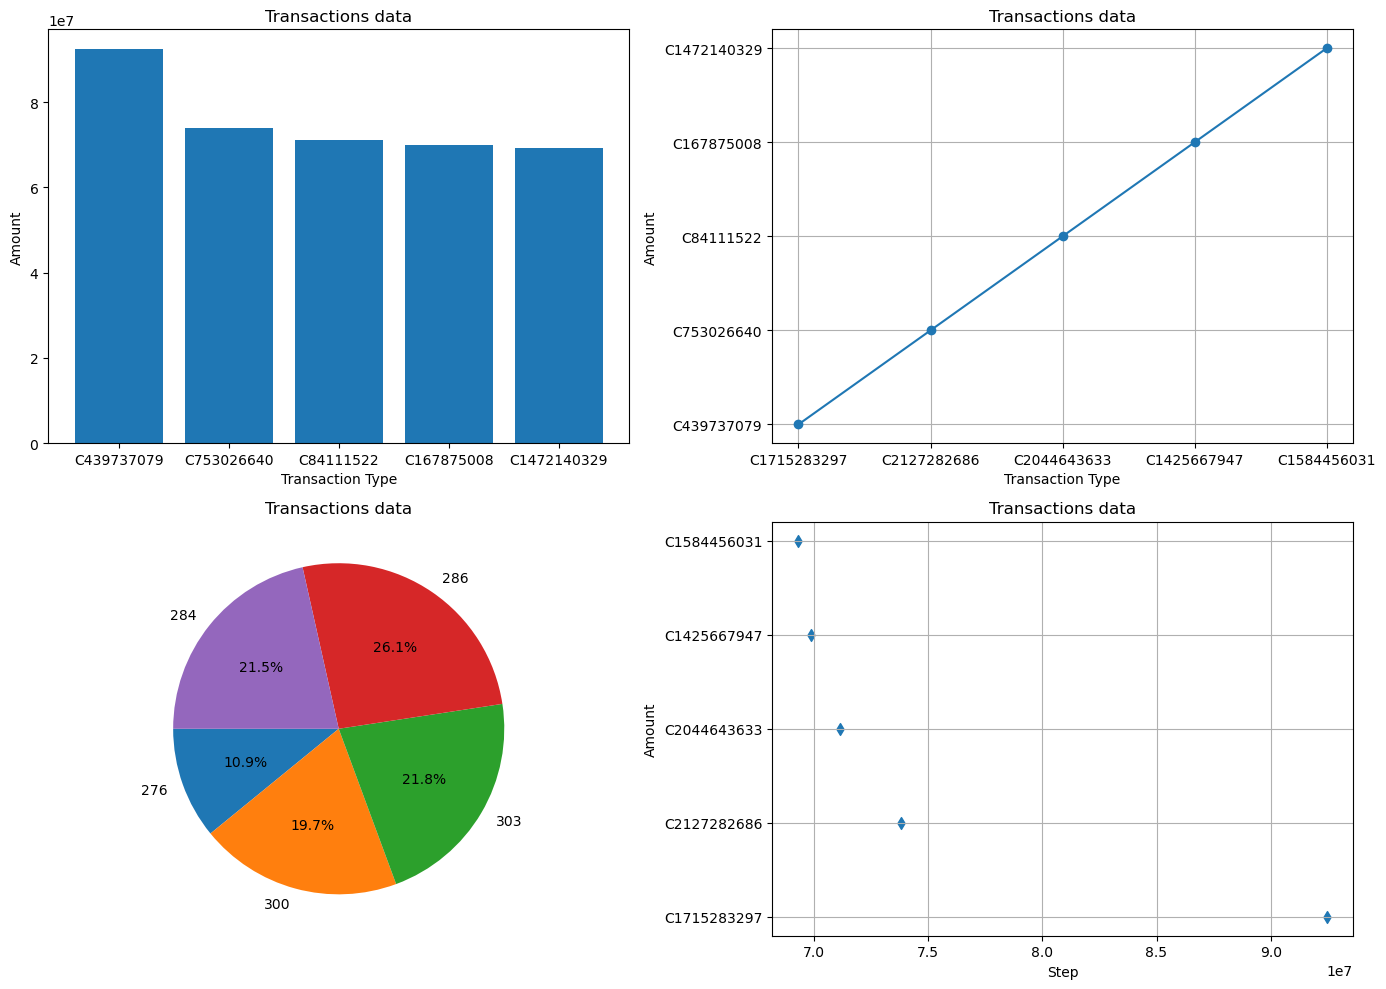

In [59]:
Transaction_data=fraud.nlargest(5,"amount")
fig,axs=plt.subplots(2,2,figsize=(14,10))
# Bar Chart
axs[0,0].bar(Transaction_data["nameDest"],Transaction_data["amount"])
axs[0,0].set_title("Transactions data")
axs[0,0].set_xlabel("Transaction Type")
axs[0,0].set_ylabel("Amount")
# Line Chart
axs[0,1].plot(Transaction_data["nameOrig"],Transaction_data["nameDest"],marker="o")
axs[0,1].grid(True)
axs[0,1].set_title("Transactions data")
axs[0,1].set_xlabel("Transaction Type")
axs[0,1].set_ylabel("Amount")
# Pie Chart
axs[1,0].pie(Transaction_data["newbalanceDest"],labels=Transaction_data["step"],autopct="%1.1f%%",startangle=180)
axs[1,0].set_title("Transactions data")
# Scatter Chart
axs[1,1].scatter(Transaction_data["amount"],Transaction_data["nameOrig"],alpha=1.0,marker="d")
axs[1,1].grid(True)
axs[1,1].set_title("Transactions data")
axs[1,1].set_xlabel("Step")
axs[1,1].set_ylabel("Amount")
plt.tight_layout()
plt.show()

In [60]:
fraud.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

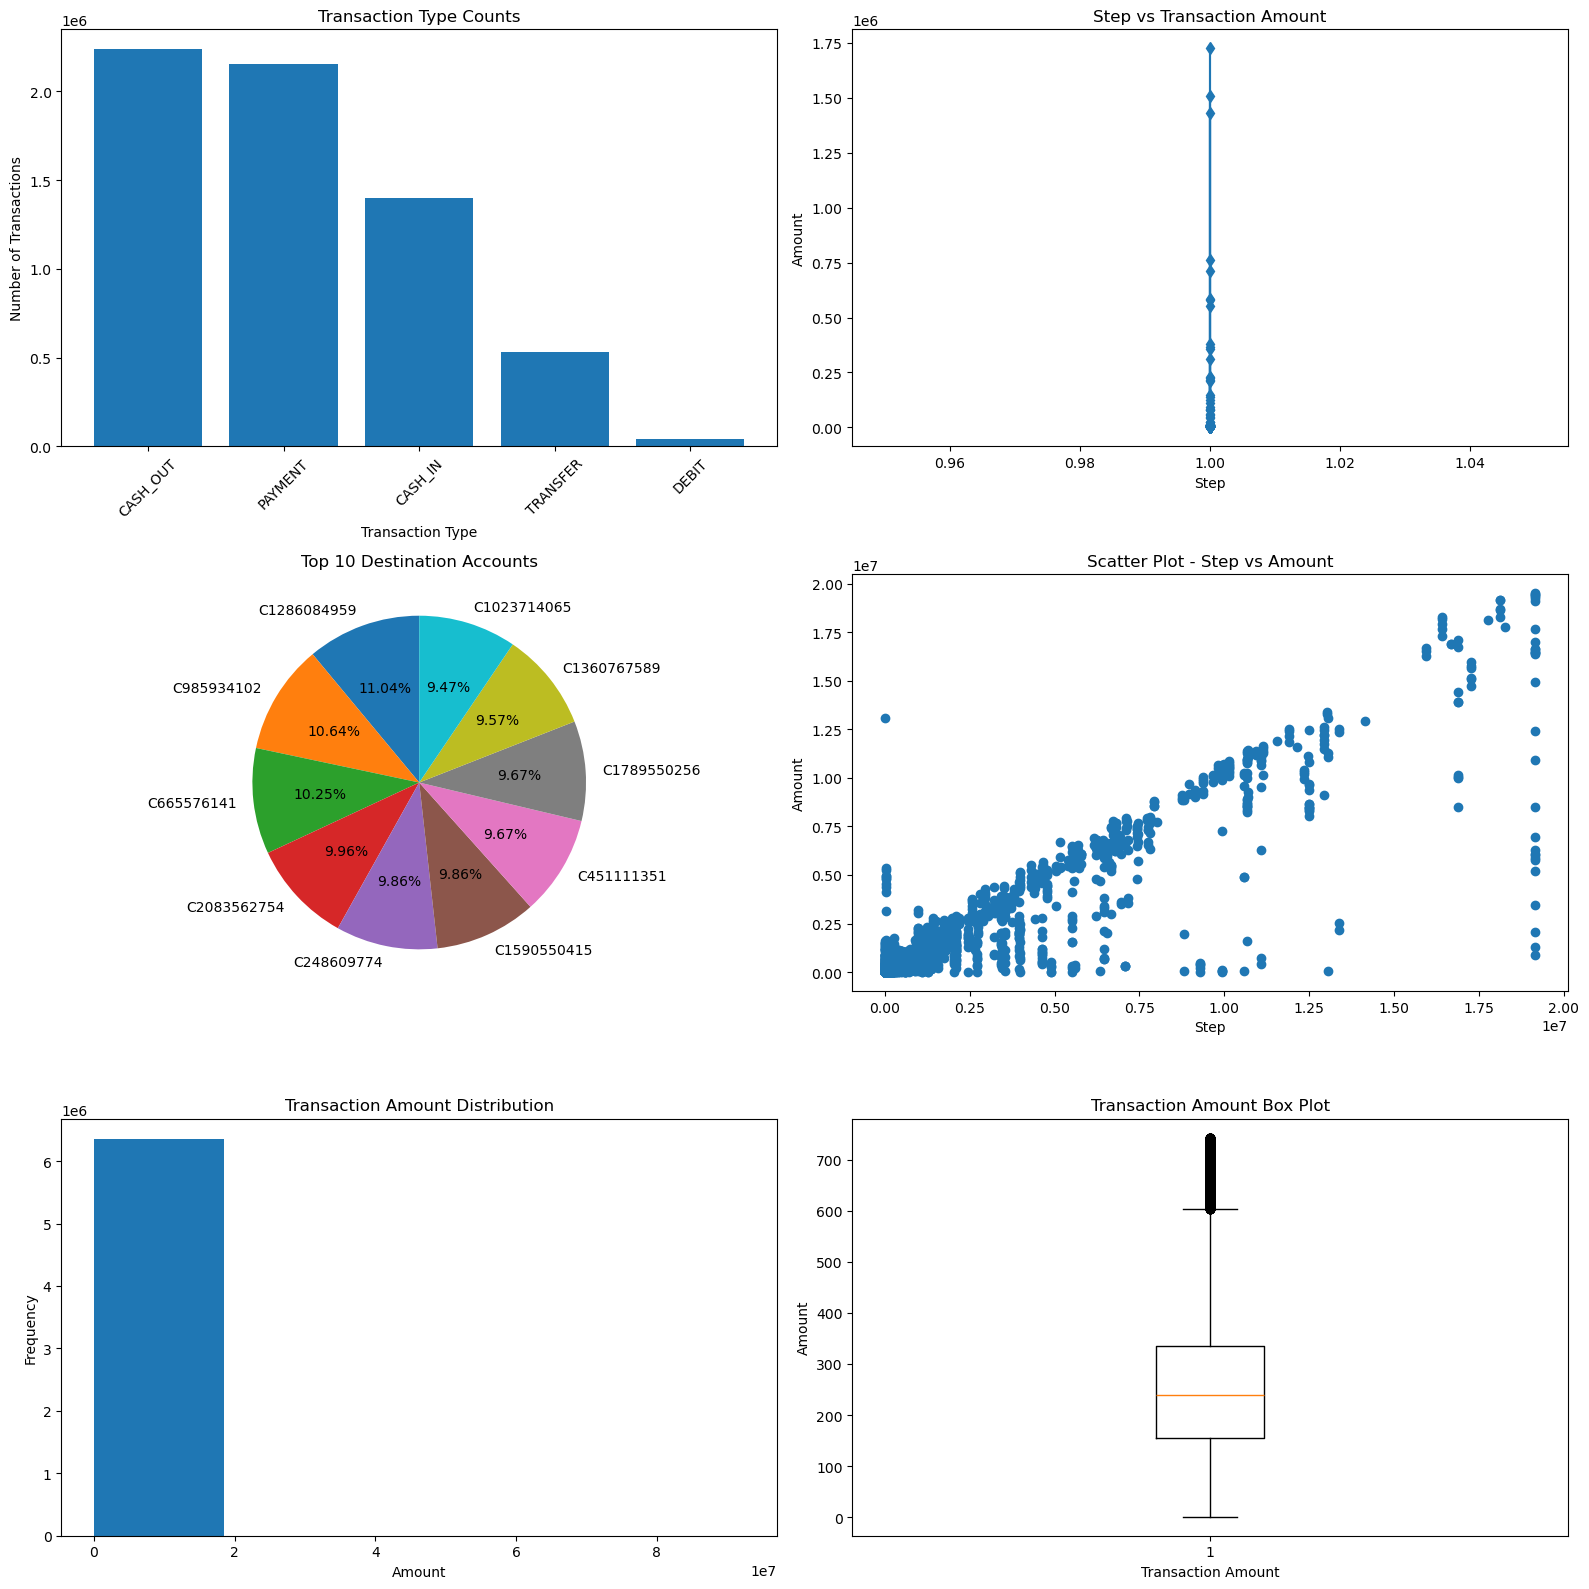

In [9]:
fig,axs=plt.subplots(3,2,figsize=(16,16))
# bar_chart
transaction_counts=fraud["type"].value_counts()
axs[0,0].bar(transaction_counts.index,transaction_counts.values)
axs[0,0].set_title("Transaction Type Counts")
axs[0,0].set_xlabel("Transaction Type")
axs[0,0].set_ylabel("Number of Transactions")
axs[0,0].tick_params(axis="x", rotation=45)
# line_chart
axs[0, 1].plot(fraud["step"].head(100),fraud["amount"].head(100),marker="d")
axs[0, 1].set_title("Step vs Transaction Amount")
axs[0, 1].set_xlabel("Step")
axs[0, 1].set_ylabel("Amount")
# pie_chart
fraud_counts=fraud["nameDest"].value_counts().head(10)
axs[1,0].pie(fraud_counts.values,labels=fraud_counts.index,autopct="%1.2f%%",startangle=90)
axs[1,0].set_title("Top 10 Destination Accounts")
#scatter_chart
axs[1,1].scatter(fraud["newbalanceDest"].head(5000),fraud["oldbalanceDest"].head(5000))
axs[1,1].set_title("Scatter Plot - Step vs Amount")
axs[1,1].set_xlabel("Step")
axs[1,1].set_ylabel("Amount")
#Histogram
axs[2,0].hist(fraud["amount"],bins=5)
axs[2,0].set_title("Transaction Amount Distribution")
axs[2,0].set_xlabel("Amount")
axs[2,0].set_ylabel("Frequency")
#box_plot
axs[2,1].boxplot(fraud["step"])
axs[2,1].set_title("Transaction Amount Box Plot")
axs[2,1].set_xlabel("Transaction Amount")
axs[2,1].set_ylabel("Amount")
plt.tight_layout()
plt.show()

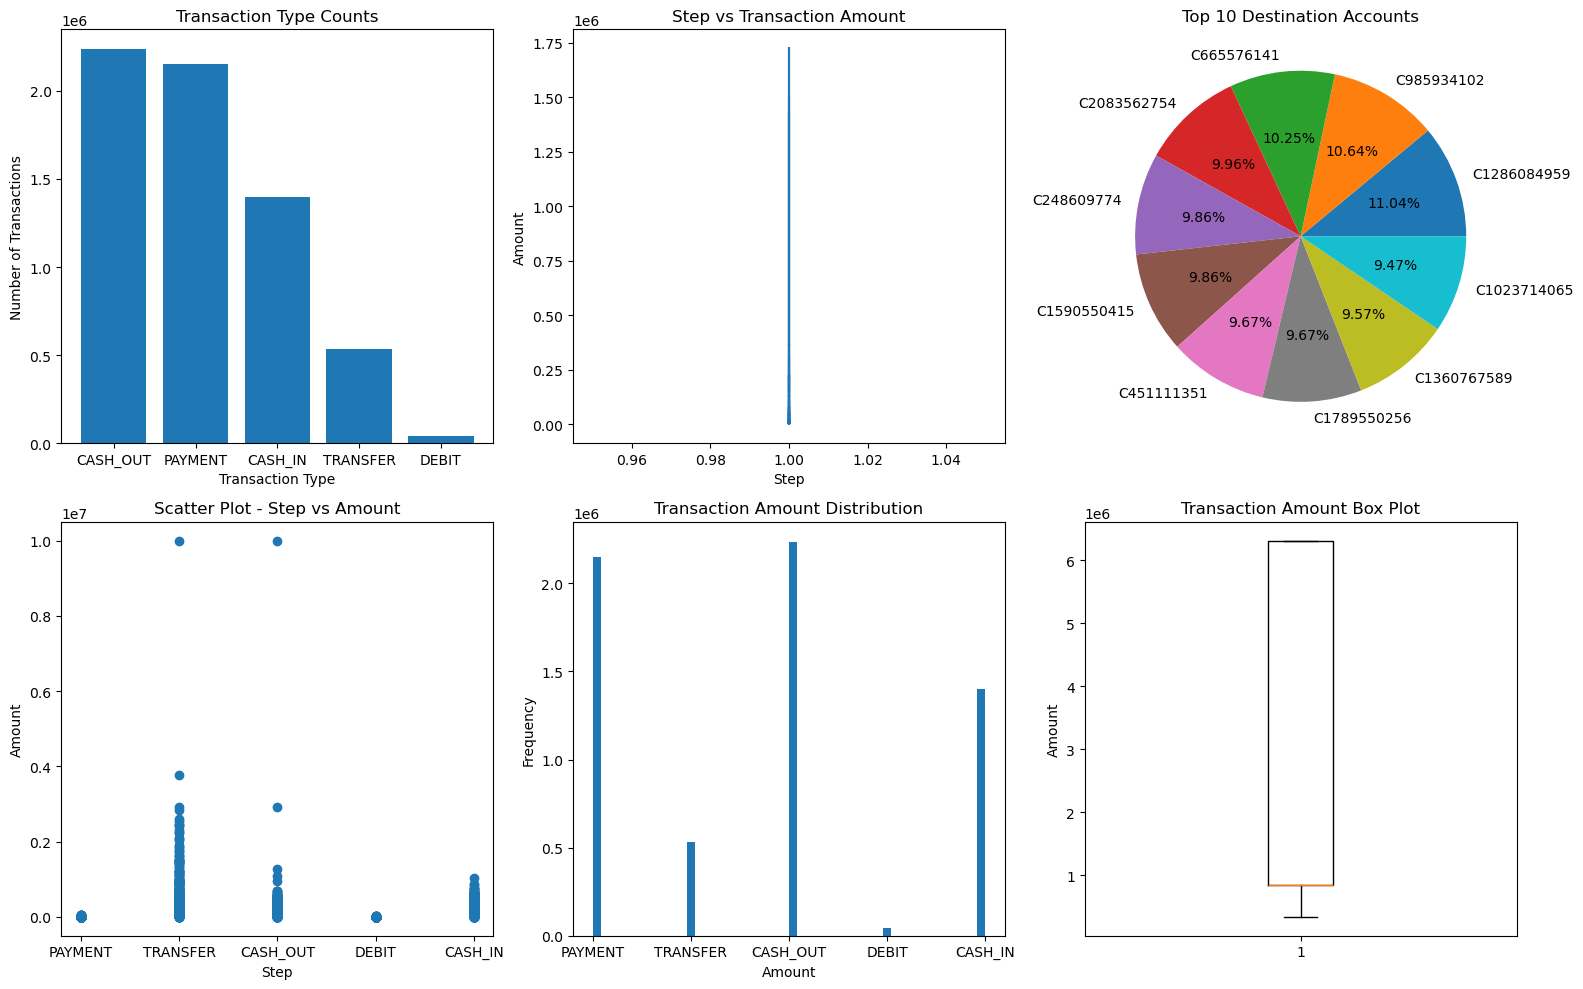

In [ ]:
fig,axs=plt.subplots(2,3,figsize=(16,10))
# Bar_chart
transaction_counts=fraud["type"].value_counts()
axs[0,0].bar(transaction_counts.index, transaction_counts.values)
axs[0,0].set_title("Transaction Type Counts")
axs[0,0].set_xlabel("Transaction Type")
axs[0,0].set_ylabel("Number of Transactions")
# Line_chart
axs[0,1].plot(fraud["step"].head(100),fraud["amount"].head(100))
axs[0,1].set_title("Step vs Transaction Amount")
axs[0,1].set_xlabel("Step")
axs[0,1].set_ylabel("Amount")
# pie_chart
fraud_counts=fraud["nameDest"].value_counts().head(10)
axs[0,2].pie(fraud_counts.values,labels=fraud_counts.index,autopct="%.2f%%")
axs[0,2].set_title("Top 10 Destination Accounts")
# scatter_chart
axs[1,0].scatter(fraud["type"].head(5000),fraud["amount"].head(5000))
axs[1,0].set_title("Scatter Plot - Step vs Amount")
axs[1,0].set_xlabel("Step")
axs[1,0].set_ylabel("Amount")
# histogram
axs[1,1].hist(fraud["type"], bins=50)
axs[1,1].set_title("Transaction Amount Distribution")
axs[1,1].set_xlabel("Amount")
axs[1,1].set_ylabel("Frequency")
# box_plot
axs[1,2].boxplot(fraud["amount"].tail())
axs[1,2].set_title("Transaction Amount Box Plot")
axs[1,2].set_ylabel("Amount")
plt.tight_layout()
plt.show()

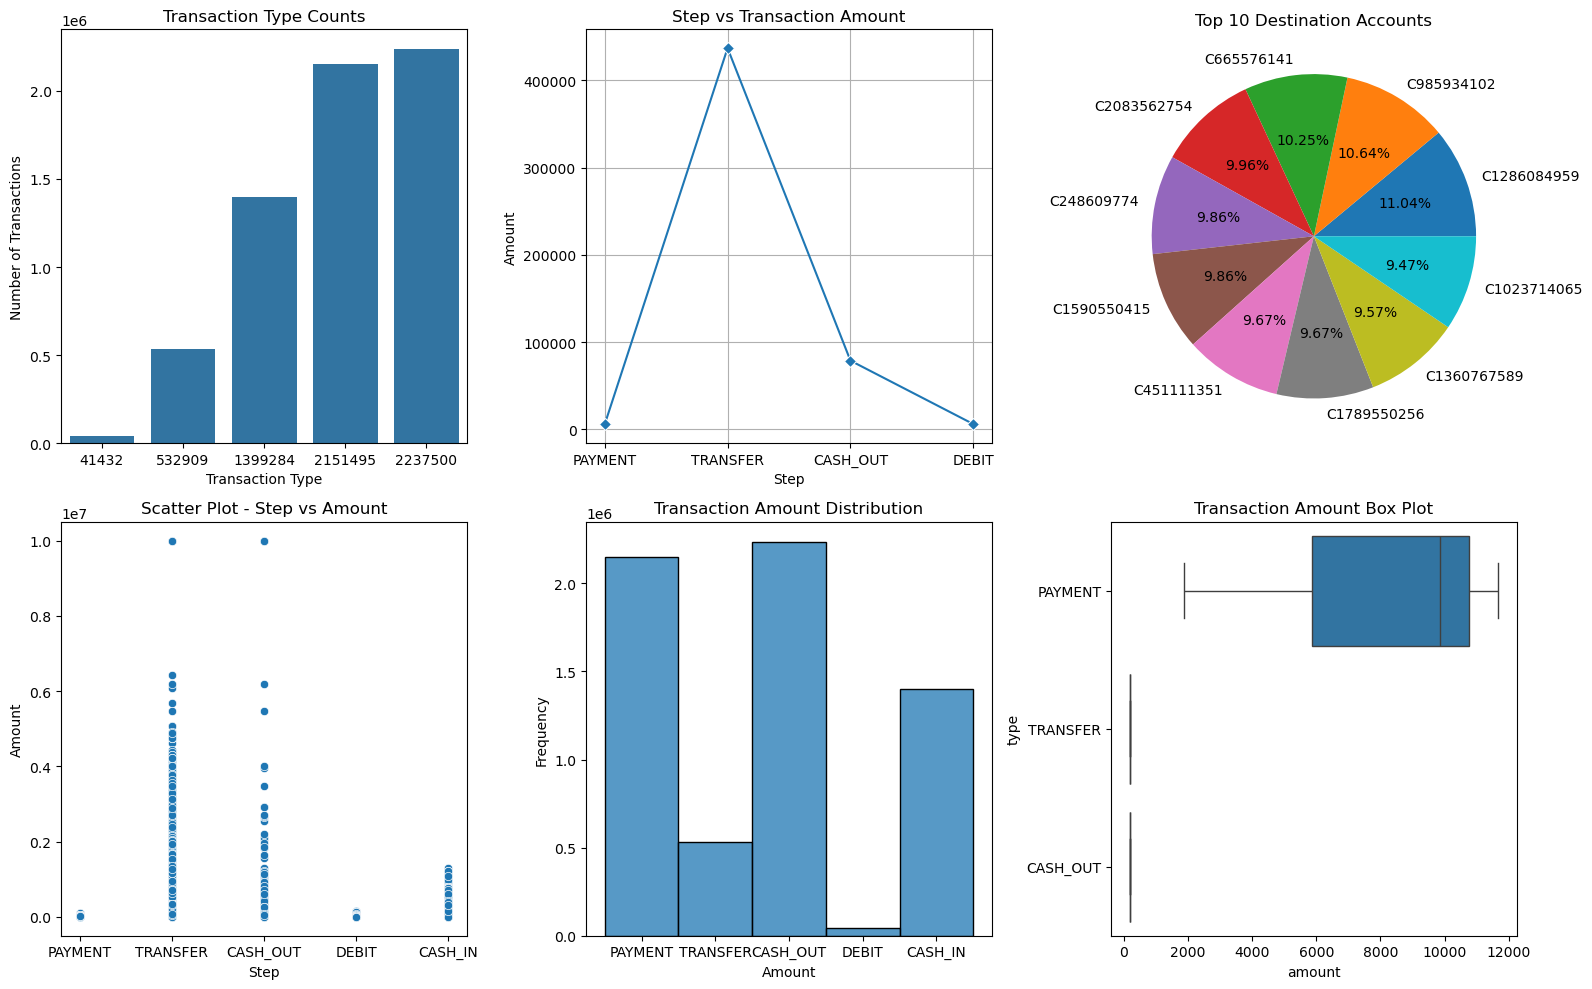

In [22]:
fig,axs=plt.subplots(2,3,figsize=(16,10))
# bar_plot
transaction_counts=fraud["type"].value_counts().head()
sns.barplot(x=transaction_counts,y=transaction_counts,ax=axs[0, 0])
axs[0,0].set_title("Transaction Type Counts")
axs[0,0].set_xlabel("Transaction Type")
axs[0,0].set_ylabel("Number of Transactions")
# line_plot
sns.lineplot(data=fraud.head(100),x="type",y="amount",ax=axs[0, 1],errorbar=None,marker="D")
axs[0,1].set_title("Step vs Transaction Amount")
axs[0,1].set_xlabel("Step")
axs[0,1].set_ylabel("Amount")
axs[0,1].grid(True)
# pie_plot
fraud_counts = fraud["nameDest"].value_counts().head(10)
axs[0,2].pie(fraud_counts.values,labels=fraud_counts.index,autopct="%.2f%%")
axs[0,2].set_title("Top 10 Destination Accounts")
# scatter_plot
sns.scatterplot(data=fraud.head(500000),x="type",y="amount",ax=axs[1, 0])
axs[1,0].set_title("Scatter Plot - Step vs Amount")
axs[1,0].set_xlabel("Step")
axs[1,0].set_ylabel("Amount")
# HISTOGRAM
sns.histplot(data=fraud,x="type",ax=axs[1, 1])
axs[1,1].set_title("Transaction Amount Distribution")
axs[1,1].set_xlabel("Amount")
axs[1,1].set_ylabel("Frequency")
# box_plot
sns.boxplot(data=fraud.head(),x="amount",y="type",ax=axs[1, 2])
axs[1,2].set_title("Transaction Amount Box Plot")
axs[1,2].set_xlabel("amount")
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------------------------Dashboards-----------------------------------------------------------------------------------

In [ ]:
fraud.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')>